# Level Detection Workbench

This notebook is a staged workbench for the hierarchy workflow.

It is meant to answer three questions in order:

1. Do the reviewed outputs look sane?
2. Does the reviewed network pass the directed-graph checks?
3. What bifurcation-confluence units and summary metrics do we get if the graph is valid?

The notebook is intentionally a validation notebook first and a metrics notebook second.

In [1]:
from pathlib import Path
import json
import sys
from importlib import reload

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidate_roots = [Path.cwd().resolve()]
candidate_roots.extend(candidate_roots[0].parents)
REPO_ROOT = next(path for path in candidate_roots if (path / "hierarchy_level_definition").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hierarchy_level_definition.metrics.unit_metrics as unit_metrics_module
import hierarchy_level_definition.metrics as metrics_package
reload(unit_metrics_module)
reload(metrics_package)

from hierarchy_level_definition.graph_building.directed_network_checks import analyze_reviewed_network
from hierarchy_level_definition.unit_detection.bifurcation_confluence_units import analyze_network
from hierarchy_level_definition.metrics import compute_unit_metrics, summarize_by_hierarchy_level
from hierarchy_level_definition.metrics.unit_metrics import compute_unit_metrics_from_units

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

REPO_ROOT


PosixPath('/Users/6256481/Code/river-hierarchy')

## 1. Review Output Inspection

Pick a reviewed example and inspect the saved link/node files before building the graph.

In [2]:
network_name = "sarl_03"

review_dir = REPO_ROOT / "hierarchy_level_definition" / "manual_review" / "outputs" / network_name
links_path = review_dir / "directed_links.gpkg"
nodes_path = review_dir / "reviewed_nodes.gpkg"

pd.Series(
    {
        "network_name": network_name,
        "review_dir": str(review_dir),
        "links_path_exists": links_path.exists(),
        "nodes_path_exists": nodes_path.exists(),
        "links_path": str(links_path),
        "nodes_path": str(nodes_path),
    }
)

network_name                                                   sarl_03
review_dir           /Users/6256481/Code/river-hierarchy/hierarchy_...
links_path_exists                                                 True
nodes_path_exists                                                 True
links_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
nodes_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
dtype: object

# 1.5

In [12]:
if not links_path.exists() or not nodes_path.exists():
    raise FileNotFoundError("Reviewed links/nodes files are missing for the selected network.")

links = gpd.read_file(links_path)
nodes = gpd.read_file(nodes_path)

print(f"links: {len(links)} rows")
print(f"nodes: {len(nodes)} rows")
print("link columns:", list(links.columns))
print("node columns:", list(nodes.columns))

display(links.head())
display(nodes.head())

links: 82 rows
nodes: 56 rows
link columns: ['id_link', 'idx_link', 'id_nodes', 'n_nodes', 'id_us_node', 'id_ds_node', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'link_conn', 'wid_pix', 'len', 'wid', 'wid_adj', 'wid_med', 'len_adj', 'sinuosity', 'manual_direction_reviewed', 'manual_us_node', 'manual_ds_node', 'geometry_reversed_manual', 'geometry']
node columns: ['id_node', 'idx_node', 'id_links', 'n_links', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'source_is_inlet', 'source_is_outlet', 'manual_role', 'node_role_reviewed', 'geometry']


,id_link,idx_link,id_nodes,n_nodes,id_us_node,id_ds_node,is_inlet,is_outlet,type_io,schema_rg,link_conn,wid_pix,len,wid,wid_adj,wid_med,len_adj,sinuosity,manual_direction_reviewed,manual_us_node,manual_ds_node,geometry_reversed_manual,geometry
0,48,"692006, 692005, 692004, 692003, 692002, 692001...","31, 34",2,31,34,False,False,neither,rg-v1,"52, 49, 45, 47","158.97096087236284, 125.67757954554364, 112.40...",1186.290687,170.307021,138.428184,125.677580,847.065180,1.082040,True,31,34,True,"LINESTRING (243310.493 7600250.068, 243338.595..."
1,52,"723019, 724836, 726653, 728470, 728469, 728468...","34, 36",2,34,36,False,False,neither,rg-v1,"53, 48, 49, 54","553.5523169568283, 530.2342889776091, 505.8425...",3321.242875,242.219392,227.309886,224.818889,2925.812646,1.076765,True,34,36,True,"LINESTRING (244265.973 7599772.328, 244294.075..."
2,49,"662905, 664724, 666542, 668361, 670179, 671998...","32, 34",2,32,34,False,False,neither,rg-v1,"48, 46, 52, 47","281.0236111114727, 231.73800638102054, 224.818...",666.810634,139.430166,120.659701,125.677580,435.172969,1.151012,True,32,34,False,"LINESTRING (243900.642 7600221.965, 243928.745..."
3,47,"661066, 659249, 657432, 657433, 659252, 659253...","31, 32",2,31,32,False,False,neither,rg-v1,"48, 46, 49, 45","428.0424119231023, 405.29801579138655, 341.879...",648.351479,282.368219,247.233916,241.546583,248.099647,1.070604,True,31,32,False,"LINESTRING (243310.493 7600250.068, 243338.595..."
4,54,"723019, 723020, 724839, 724840, 726659, 726660...","36, 37",2,36,37,False,False,neither,rg-v1,"53, 52, 55, 56","553.5523169568283, 605.3433842125422, 562.0472...",812.144043,531.186763,490.359498,502.710318,208.356907,1.048528,True,36,37,False,"LINESTRING (247272.926 7599294.587, 247301.028..."


,id_node,idx_node,id_links,n_links,is_inlet,is_outlet,type_io,schema_rg,source_is_inlet,source_is_outlet,manual_role,node_role_reviewed,geometry
0,34,692006,"48, 52, 49",3,False,False,neither,rg-v1,False,False,internal,True,POINT (244265.973 7599772.328)
1,31,661066,"48, 47, 45",3,False,False,neither,rg-v1,False,False,internal,True,POINT (243310.493 7600250.068)
2,36,723019,"52, 54, 53",3,False,False,neither,rg-v1,False,False,internal,True,POINT (247272.926 7599294.587)
3,32,662905,"49, 46, 47",3,False,False,neither,rg-v1,False,False,internal,True,POINT (243900.642 7600221.965)
4,37,735771,"54, 55, 56",3,False,False,neither,rg-v1,False,False,internal,True,POINT (248003.587 7599097.871)


In [13]:
review_summary = pd.Series(
    {
        "n_links": len(links),
        "n_nodes": len(nodes),
        "n_flagged_inlets": int(nodes["is_inlet"].fillna(False).astype(bool).sum()) if "is_inlet" in nodes.columns else None,
        "n_flagged_outlets": int(nodes["is_outlet"].fillna(False).astype(bool).sum()) if "is_outlet" in nodes.columns else None,
        "n_reversed_geometries": int(links["geometry_reversed_manual"].fillna(False).astype(bool).sum()) if "geometry_reversed_manual" in links.columns else None,
        "manual_role_counts": nodes["manual_role"].value_counts(dropna=False).to_dict() if "manual_role" in nodes.columns else None,
    }
)

review_summary

n_links                                                         82
n_nodes                                                         56
n_flagged_inlets                                                 1
n_flagged_outlets                                                1
n_reversed_geometries                                           45
manual_role_counts       {'internal': 54, 'outlet': 1, 'inlet': 1}
dtype: object

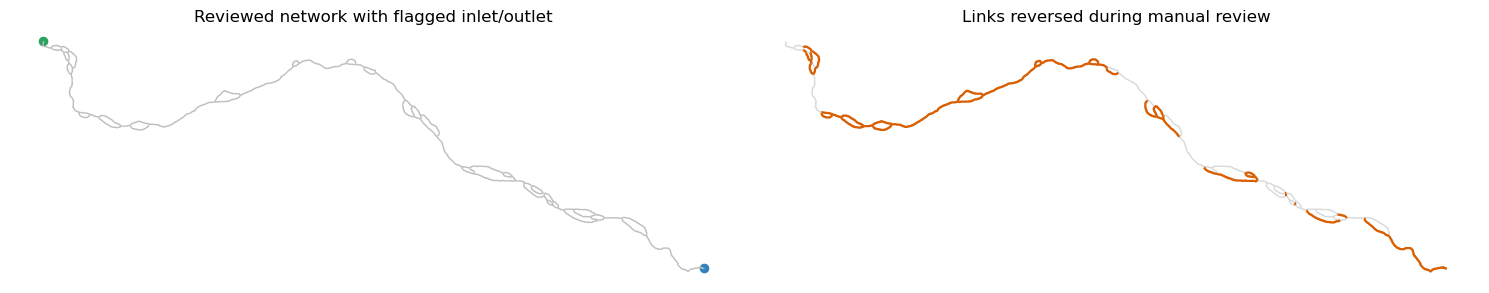

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

links.plot(ax=axes[0], color="0.75", linewidth=1)
if "is_inlet" in nodes.columns:
    nodes.loc[nodes["is_inlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#2ca25f", markersize=35)
if "is_outlet" in nodes.columns:
    nodes.loc[nodes["is_outlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#3182bd", markersize=35)
axes[0].set_title("Reviewed network with flagged inlet/outlet")
axes[0].set_axis_off()

links.plot(ax=axes[1], color="0.85", linewidth=1)
if "geometry_reversed_manual" in links.columns:
    reversed_links = links.loc[links["geometry_reversed_manual"].fillna(False).astype(bool)]
    if not reversed_links.empty:
        reversed_links.plot(ax=axes[1], color="#d95f02", linewidth=1.6)
axes[1].set_title("Links reversed during manual review")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# 2. Graph Validation Diagnostics

Build the directed graph from the reviewed files and treat this as a validation gate.

We want exactly one source/inlet, exactly one sink/outlet, no isolated nodes, and no extra local minima/maxima.

In [6]:
import networkx as nx 

In [7]:
# [n for n in graph.nodes() if graph.out_degree(n) > 1]

In [16]:
graph, degree_frame, report = analyze_reviewed_network(links_path, nodes_path)
report_dict = report.to_dict()

In [9]:
issues = pd.DataFrame({"issue": report.issues}) if report.issues else pd.DataFrame({"issue": ["No issues. Graph passes the current validation checks."]})
sources = degree_frame.loc[degree_frame["is_source"]]
sinks = degree_frame.loc[degree_frame["is_sink"]]
isolated = degree_frame.loc[degree_frame["is_isolated"]]
flagged = degree_frame.loc[degree_frame["flag_is_inlet"] | degree_frame["flag_is_outlet"]]

display(issues)
display(sources)
display(sinks)
display(isolated)
display(flagged)

,issue
0,No issues. Graph passes the current validation...


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
17,17,0,1,1,0,1,0,1,True,False,False,True,False


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,1,0,1,1,0,1,0,False,True,False,False,True


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,1,0,1,1,0,1,0,False,True,False,False,True
17,17,0,1,1,0,1,0,1,True,False,False,True,False


## 2.5


In [10]:
# if not report.is_valid:
#     raise ValueError("Graph validation failed. Fix the reviewed network before running unit detection.")

# summary, units, hierarchy = analyze_network(links_path, nodes_path)
# unit_metrics, path_metrics = compute_unit_metrics_from_units(links, units)

# print(f"Detected {len(units)} unit(s).")
# display(summary)
# display(unit_metrics)


if path_metrics.empty:
    print("No path-level metrics detected for this network.")
else:
    display(path_metrics)
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_compound_units",
                "n_leaf_units",
                "max_depth_from_root",
                "max_collapse_level",
                "median_equivalent_length",
                "median_equivalent_width",
                "median_elongation",
            ],
            "value": [
                len(unit_metrics),
                int(unit_metrics["is_compound"].fillna(False).sum()),
                int((~unit_metrics["is_compound"].fillna(False)).sum()),
                unit_metrics["depth_from_root"].max(),
                unit_metrics["collapse_level"].max(),
                unit_metrics["equivalent_length"].median(),
                unit_metrics["equivalent_width"].median(),
                unit_metrics["elongation"].median(),
            ],
        }
    )
    display(metrics_table)


In [11]:
if unit_metrics.empty:
    print("No unit plots to show.")
else:
    class_counts = unit_metrics["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].scatter(unit_metrics["equivalent_width"], unit_metrics["equivalent_length"], c=unit_metrics["n_paths"], cmap="viridis", s=50)
    axes[1].set_title("Equivalent width vs equivalent length")
    axes[1].set_xlabel("equivalent_width")
    axes[1].set_ylabel("equivalent_length")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.hlines(unit_metrics["unit_id"], unit_metrics["path_length_min"], unit_metrics["path_length_max"], color="0.45")
    ax.scatter(unit_metrics["path_length_min"], unit_metrics["unit_id"], color="#2ca25f", label="min")
    ax.scatter(unit_metrics["path_length_max"], unit_metrics["unit_id"], color="#3182bd", label="max")
    ax.set_title("Path-length range by unit")
    ax.set_xlabel("path length")
    ax.set_ylabel("unit_id")
    ax.legend()
    plt.tight_layout()
    plt.show()


NameError: name 'unit_metrics' is not defined

In [ ]:
if summary.empty:
    print("No units detected for this network.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_unique_bifurcations",
                "n_unique_confluences",
                "min_n_paths",
                "max_n_paths",
                "median_n_paths",
                "min_path_length_min",
                "max_path_length_max",
            ],
            "value": [
                len(summary),
                summary["bifurcation"].nunique(),
                summary["confluence"].nunique(),
                summary["n_paths"].min(),
                summary["n_paths"].max(),
                summary["n_paths"].median(),
                summary["min_path_length"].min(),
                summary["max_path_length"].max(),
            ],
        }
    )

    display(class_counts)
    display(metrics_table)

,class,n_units
0,simple_bifurcation_confluence_pair,5
1,compound_or_nested_complex,3


,metric,value
0,n_units,8.000000
1,n_unique_bifurcations,8.000000
2,n_unique_confluences,8.000000
3,min_n_paths,2.000000
4,max_n_paths,2.000000
5,median_n_paths,2.000000
6,min_path_length_min,900.890338
7,max_path_length_max,5689.563891


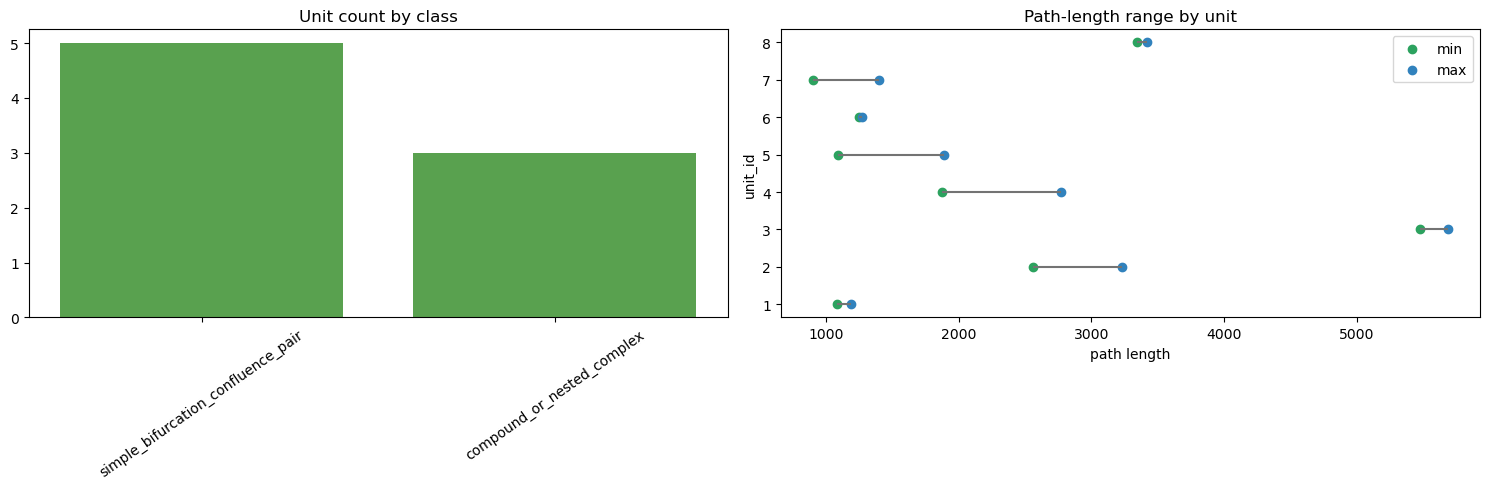

In [ ]:
if summary.empty:
    print("No unit plots to show.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].hlines(summary["unit_id"], summary["min_path_length"], summary["max_path_length"], color="0.45")
    axes[1].scatter(summary["min_path_length"], summary["unit_id"], color="#2ca25f", label="min")
    axes[1].scatter(summary["max_path_length"], summary["unit_id"], color="#3182bd", label="max")
    axes[1].set_title("Path-length range by unit")
    axes[1].set_xlabel("path length")
    axes[1].set_ylabel("unit_id")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def hierarchy_lines(nodes, indent=0):
    lines = []
    for node in nodes:
        lines.append(
            "  " * indent
            + f"unit {node['unit_id']}: bif={node['bifurcation']}, conf={node['confluence']}, paths={node['n_paths']}, class={node['class']}"
        )
        lines.extend(hierarchy_lines(node["children"], indent + 1))
    return lines

if hierarchy:
    print("\n".join(hierarchy_lines(hierarchy)))
else:
    print("Hierarchy is empty.")

unit 1: bif=2, conf=1, paths=2, class=simple_bifurcation_confluence_pair
unit 2: bif=4, conf=3, paths=2, class=simple_bifurcation_confluence_pair
unit 3: bif=6, conf=5, paths=2, class=simple_bifurcation_confluence_pair
unit 4: bif=8, conf=7, paths=2, class=simple_bifurcation_confluence_pair
unit 5: bif=10, conf=9, paths=2, class=simple_bifurcation_confluence_pair
unit 6: bif=14, conf=11, paths=2, class=compound_or_nested_complex
unit 7: bif=15, conf=12, paths=2, class=compound_or_nested_complex
unit 8: bif=16, conf=13, paths=2, class=compound_or_nested_complex


In [ ]:
# tejedor 

# 4

In [3]:
from pathlib import Path
import sys
from importlib import reload

candidate_roots = [Path.cwd().resolve()]
candidate_roots.extend(candidate_roots[0].parents)
REPO_ROOT = next(path for path in candidate_roots if (path / "hierarchy_level_definition").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hierarchy_level_definition.metrics.unit_metrics as unit_metrics_module
import hierarchy_level_definition.metrics as metrics_package
reload(unit_metrics_module)
reload(metrics_package)

from hierarchy_level_definition.metrics import compute_unit_metrics, summarize_by_hierarchy_level


In [4]:
summary, unit_metrics, path_metrics = compute_unit_metrics(
    links_path,
    nodes_path,
    pixel_width_fields=["wid_pix"],
    pixel_width_percentiles=(5, 50, 95),
    use_pixel_widths_for_extremes=True,
)


In [5]:
hierarchy_level_metrics = summarize_by_hierarchy_level(unit_metrics)
display(hierarchy_level_metrics)


,collapse_level,n_units,n_compound_units,n_leaf_units,mean_equivalent_width,median_equivalent_width,sum_equivalent_width,mean_equivalent_length,median_equivalent_length,mean_elongation,median_elongation,mean_n_paths,mean_n_valid_paths,mean_effective_n_paths_width,mean_width_evenness,mean_largest_path_width_fraction,mean_topologic_complexity_score,mean_dynamic_proxy_complexity_score,width_weighted_mean_elongation,width_weighted_mean_effective_n_paths_width,width_weighted_mean_width_evenness,width_weighted_mean_topologic_complexity_score,width_weighted_mean_dynamic_proxy_complexity_score
0,0,25,0,25,330.374265,322.208836,8259.356620,986.634854,701.378428,3.111177,2.501807,2.0,2.0,1.887923,0.913452,0.636345,1.722716,0.913452,2.986416,1.864820,0.895379,1.619567,0.895379
1,1,2,2,0,653.003203,653.003203,1306.006406,2484.149821,2484.149821,4.374438,4.374438,3.0,3.0,2.837122,0.948289,0.475401,3.178054,0.948289,3.804192,2.807884,0.938902,3.178054,0.938902


In [11]:
path_metrics[['unit_id', 'path_width_fraction', 'path_length_fraction']]

,unit_id,path_width_fraction,path_length_fraction
0,1,0.387404,0.730752
1,1,0.612596,0.269248
2,2,0.493174,0.539904
3,2,0.506826,0.460096
4,3,0.408738,0.628694
5,3,0.591262,0.371306
6,4,0.497759,0.512887
7,4,0.502241,0.487113
8,5,0.178643,0.650412
9,5,0.821357,0.349588


In [7]:
unit_metrics.columns

Index(['unit_id', 'bifurcation', 'confluence', 'class', 'n_paths', 'n_valid_paths', 'equivalent_width', 'equivalent_length', 'elongation',
       'path_length_min', 'path_length_max', 'path_length_mean', 'path_length_range', 'path_length_range_norm', 'path_length_cv',
       'path_width_eq_min', 'path_width_eq_max', 'path_width_eq_mean', 'path_width_range', 'path_width_range_norm',
       'largest_path_width_fraction', 'dominant_width_fraction', 'width_entropy', 'width_evenness', 'effective_n_paths_width',
       'path_disparity_width', 'width_ratio_2', 'smaller_width_fraction_2', 'dominant_width_fraction_2', 'length_ratio_2',
       'internal_bifurcation_count', 'internal_confluence_count', 'total_bifurcation_count', 'total_confluence_count',
       'internal_branch_node_count', 'branching_density_by_length', 'path_redundancy', 'compound_indicator', 'topologic_complexity_score',
       'dynamic_proxy_method', 'dynamic_proxy_weight_field', 'dynamic_proxy_entropy', 'effective_n_paths_dy

In [14]:
unit_metrics[['unit_id', 'n_paths', 'n_valid_paths', 'equivalent_width', 'equivalent_length', 'elongation',
       'compound_unit_id', 'compound_bubble_id', 'in_compound_bubble','largest_path_width_fraction','dominant_width_fraction',
       'width_entropy', 'width_evenness', 'effective_n_paths_width',
       'internal_bifurcation_count', 'internal_confluence_count', 'total_bifurcation_count', 'total_confluence_count',
       'internal_branch_node_count', 'branching_density_by_length', 'path_redundancy', 'compound_indicator', 'topologic_complexity_score',
       'dynamic_proxy_method', 'dynamic_proxy_weight_field', 'dynamic_proxy_entropy', 'effective_n_paths_dyn_width',
       'dominant_dyn_fraction_width', 'dynamic_proxy_complexity_score',
       'path_disparity_width', 'width_ratio_2', 'smaller_width_fraction_2', 'dominant_width_fraction_2', 'length_ratio_2',
       'compound_bubble_role', 'unit_node_ids', 'unit_topodynamic_class']].sort_values('compound_bubble_id')

,unit_id,n_paths,n_valid_paths,equivalent_width,equivalent_length,elongation,compound_unit_id,compound_bubble_id,in_compound_bubble,largest_path_width_fraction,dominant_width_fraction,width_entropy,width_evenness,effective_n_paths_width,internal_bifurcation_count,internal_confluence_count,total_bifurcation_count,total_confluence_count,internal_branch_node_count,branching_density_by_length,path_redundancy,compound_indicator,topologic_complexity_score,dynamic_proxy_method,dynamic_proxy_weight_field,dynamic_proxy_entropy,effective_n_paths_dyn_width,dominant_dyn_fraction_width,dynamic_proxy_complexity_score,path_disparity_width,width_ratio_2,smaller_width_fraction_2,dominant_width_fraction_2,length_ratio_2,compound_bubble_role,unit_node_ids,unit_topodynamic_class
0,1,2,2,212.364706,478.977946,2.255450,<NA>,1,True,0.612596,0.612596,0.667573,0.963104,1.949500,2,1,3,2,3,0.006263,1,0,2.890372,path_equivalent_width_fraction,path_width_eq,0.667573,1.949500,0.612596,0.963104,1.025904,0.632398,0.387404,0.612596,0.368454,bubble_member,"1,3,4,5,6",intermediate_unit
1,2,2,2,322.208836,673.308601,2.089665,<NA>,1,True,0.506826,0.506826,0.693054,0.999866,1.999814,1,0,2,1,1,0.001485,1,0,1.791759,path_equivalent_width_fraction,path_width_eq,0.693054,1.999814,0.506826,0.999866,1.000093,0.973062,0.493174,0.506826,0.852181,bubble_root,"1,2,3",intermediate_unit
2,3,2,2,225.570169,1204.013325,5.337644,<NA>,1,True,0.591262,0.591262,0.676396,0.975833,1.966777,1,2,2,3,3,0.002492,1,0,2.890372,path_equivalent_width_fraction,path_width_eq,0.676396,1.966777,0.591262,0.975833,1.016892,0.691298,0.408738,0.591262,0.590600,bubble_member,"4,6,7,10,14",intermediate_unit
3,4,2,2,223.815843,583.848319,2.608610,<NA>,1,True,0.502241,0.502241,0.693137,0.999986,1.999980,0,1,1,2,1,0.001713,1,0,1.791759,path_equivalent_width_fraction,path_width_eq,0.693137,1.999980,0.502241,0.999986,1.000010,0.991077,0.497759,0.502241,0.949747,bubble_member,"5,6,7",intermediate_unit
5,6,2,2,281.082541,605.023906,2.152478,<NA>,1,True,0.622473,0.622473,0.662840,0.956276,1.940295,0,1,1,2,1,0.001653,1,0,1.791759,path_equivalent_width_fraction,path_width_eq,0.662840,1.940295,0.622473,0.956276,1.030771,0.606494,0.377527,0.622473,0.782557,bubble_member,"10,14,16",intermediate_unit
11,12,2,2,371.111456,644.513969,1.736713,<NA>,2,False,0.682760,0.682760,0.624772,0.901355,1.867819,0,0,1,1,0,0.000000,1,0,1.098612,path_equivalent_width_fraction,path_width_eq,0.624772,1.867819,0.682760,0.901355,1.070767,0.464644,0.317240,0.682760,0.704633,standalone,"21,22",dominant_simple_split
13,14,2,2,355.125762,1717.578789,4.836537,<NA>,3,False,0.725846,0.725846,0.587346,0.847362,1.799208,0,0,1,1,0,0.000000,1,0,1.098612,path_equivalent_width_fraction,path_width_eq,0.587346,1.799208,0.725846,0.847362,1.111600,0.377702,0.274154,0.725846,0.951567,standalone,"25,29",dominant_simple_split
14,15,2,2,497.594040,1244.884461,2.501807,<NA>,4,False,0.772211,0.772211,0.536591,0.774138,1.710167,0,0,1,1,0,0.000000,1,0,1.098612,path_equivalent_width_fraction,path_width_eq,0.536591,1.710167,0.772211,0.774138,1.169476,0.294983,0.227789,0.772211,0.880563,standalone,"27,28",dominant_simple_split
9,10,2,2,442.224800,1808.637678,4.089860,<NA>,5,False,0.712826,0.712826,0.599602,0.865042,1.821393,0,0,1,1,0,0.000000,1,0,1.098612,path_equivalent_width_fraction,path_width_eq,0.599602,1.821393,0.712826,0.865042,1.098061,0.402866,0.287174,0.712826,0.837858,standalone,"17,19",dominant_simple_split
6,7,2,2,454.527029,240.123073,0.528292,<NA>,6,False,0.730291,0.730291,0.582969,0.841046,1.791349,0,0,1,1,0,0.000000,1,0,1.098612,path_equivalent_width_fraction,path_width_eq,0.582969,1.791349,0.730291,0.841046,1.116477,0.369317,0.269709,0.730291,0.299832,standalone,"8,12",dominant_simple_split


In [10]:
summary

,unit_id,bifurcation,confluence,n_paths,class,min_path_length,max_path_length,unit_node_ids,unit_node_count,internal_bifurcations,internal_confluences,children,parents,primary_parent_id,root_unit_id,depth_from_root,collapse_level,n_children,n_descendants,is_compound,path_cutoff_used,path_enumeration_truncated,compound_unit_id,compound_bubble_id,in_compound_bubble,compound_bubble_role
0,1,1,6,2,compound_or_nested_complex,287.842387,781.217252,"1,3,4,5,6",5,"[4, 5]",[3],[],[],<NA>,1,0,0,0,0,False,4,False,<NA>,1,True,bubble_member
1,2,2,3,2,compound_or_nested_complex,620.249118,727.836959,"1,2,3",3,[1],[],[],[],<NA>,2,0,0,0,0,False,2,False,<NA>,1,True,bubble_root
2,3,4,14,2,compound_or_nested_complex,938.191040,1588.539692,"4,6,7,10,14",5,[10],"[6, 7]",[],[],<NA>,3,0,0,0,0,False,4,False,<NA>,1,True,bubble_member
3,4,5,7,2,compound_or_nested_complex,568.865998,598.965533,"5,6,7",3,[],[6],[],[],<NA>,4,0,0,0,0,False,2,False,<NA>,1,True,bubble_member
4,5,9,11,2,simple_bifurcation_confluence_pair,388.611453,723.015356,"9,11",2,[],[],[],[],<NA>,5,0,0,0,0,False,1,False,<NA>,7,False,standalone
5,6,10,16,2,compound_or_nested_complex,547.582414,699.734598,"10,14,16",3,[],[14],[],[],<NA>,6,0,0,0,0,False,2,False,<NA>,1,True,bubble_member
6,7,12,8,2,simple_bifurcation_confluence_pair,147.330582,491.377691,"8,12",2,[],[],[],[],<NA>,7,0,0,0,0,False,1,False,<NA>,6,False,standalone
7,8,13,15,2,simple_bifurcation_confluence_pair,699.734598,858.705559,"13,15",2,[],[],[],[],<NA>,8,0,0,0,0,False,1,False,<NA>,8,False,standalone
8,9,18,24,2,compound_or_nested_complex,1069.059639,1518.697417,"18,20,24",3,[20],[],[],[],<NA>,9,0,0,0,0,False,2,False,<NA>,9,True,bubble_root
9,10,19,17,2,simple_bifurcation_confluence_pair,1713.416772,2044.996246,"17,19",2,[],[],[],[],<NA>,10,0,0,0,0,False,1,False,<NA>,5,False,standalone
